In [11]:
# 导入
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATA_ROOT = Path(r"E:\桌面\各种作业的东西\人工智能微专业\计算机视觉基础\实验 阶段2\交大视觉印象数据集2026")

In [3]:
retrieval_root = DATA_ROOT / "image_retrieval"
base_dir = retrieval_root / "base"
query_dir = retrieval_root / "query"

det_data_dir = DATA_ROOT / "object_detection" / "data"

output_root = Path("outputs")
pk_curve_dir = output_root / "pk_curves"
text_det_dir = output_root / "text_detection_detectonly_final"
feature_dir = output_root / "features"

for d in [output_root, pk_curve_dir, text_det_dir, feature_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("base_dir:", base_dir.exists(), base_dir)
print("query_dir:", query_dir.exists(), query_dir)
print("det_data_dir:", det_data_dir.exists(), det_data_dir)

base_dir: True E:\桌面\各种作业的东西\人工智能微专业\计算机视觉基础\实验 阶段2\交大视觉印象数据集2026\image_retrieval\base
query_dir: True E:\桌面\各种作业的东西\人工智能微专业\计算机视觉基础\实验 阶段2\交大视觉印象数据集2026\image_retrieval\query
det_data_dir: True E:\桌面\各种作业的东西\人工智能微专业\计算机视觉基础\实验 阶段2\交大视觉印象数据集2026\object_detection\data


In [4]:
# 读取图片路径，定义标签函数
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

LANDMARKS = ["fhy", "jx", "kx", "mh", "nm", "sjz", "sy", "tsg", "ty", "yf", "yk", "zx"]

def get_label(path):
    return path.stem.split("-")[0]

base_imgs = sorted([p for p in base_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])
query_imgs = sorted([p for p in query_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])
det_img_paths = sorted([p for p in det_data_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

print("base 图片数量:", len(base_imgs))
print("query 图片数量:", len(query_imgs))
print("文字检测 data 图片数量:", len(det_img_paths))

print("前5个 query:", [p.name for p in query_imgs[:5]])
print("前5个 base:", [p.name for p in base_imgs[:5]])

base 图片数量: 7728
query 图片数量: 135
文字检测 data 图片数量: 1494
前5个 query: ['fhy-12k4jb1k421.jpg', 'fhy-20250506194938.jpg', 'fhy-202505071933041.jpg', 'fhy-20260511140018_130_105(1).jpg', 'fhy-2837bfg872vd.jpg']
前5个 base: ['fhy-0120240508151840.jpg', 'fhy-02wfiftgcgghjxr.jpg', 'fhy-04qgjnsjosp902psvnz.png', 'fhy-0589095011.png', 'fhy-08ur03qu0ridjewifi.jpg']


In [5]:
#过滤了一张坏图
def filter_valid_images(paths):
    valid = []
    bad = []

    for p in paths:
        try:
            with Image.open(p) as img:
                img.verify()
            valid.append(p)
        except Exception:
            bad.append(p)

    return valid, bad

base_imgs, bad_base_imgs = filter_valid_images(base_imgs)
query_imgs, bad_query_imgs = filter_valid_images(query_imgs)

print("有效 base:", len(base_imgs))
print("坏 base:", len(bad_base_imgs))
print("有效 query:", len(query_imgs))
print("坏 query:", len(bad_query_imgs))

if bad_base_imgs:
    print("坏图示例:", [p.name for p in bad_base_imgs[:10]])

有效 base: 7727
坏 base: 1
有效 query: 135
坏 query: 0
坏图示例: ['ty-1746580766456.jpg']


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("torch version:", torch.__version__)
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

class ImagePathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), str(path)

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.fc = nn.Identity()
model = model.to(device)
model.eval()

print("ResNet50 feature extractor loaded.")

torch version: 2.5.1+cu121
device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
ResNet50 feature extractor loaded.


In [7]:
@torch.no_grad()
def extract_features(paths, batch_size=64):
    ds = ImagePathDataset(paths, transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    feats = []
    out_paths = []

    for imgs, batch_paths in dl:
        imgs = imgs.to(device)
        f = model(imgs)
        f = torch.nn.functional.normalize(f, dim=1)

        feats.append(f.cpu().numpy())
        out_paths.extend(batch_paths)

    feats = np.concatenate(feats, axis=0)
    out_paths = [Path(p) for p in out_paths]

    return feats, out_paths


base_feat_file = feature_dir / "base_feats.npy"
query_feat_file = feature_dir / "query_feats.npy"
base_path_file = feature_dir / "base_paths.npy"
query_path_file = feature_dir / "query_paths.npy"

if base_feat_file.exists() and query_feat_file.exists() and base_path_file.exists() and query_path_file.exists():
    print("发现已有特征文件，直接加载。")
    base_feats = np.load(base_feat_file)
    query_feats = np.load(query_feat_file)
    base_paths = [Path(p) for p in np.load(base_path_file, allow_pickle=True)]
    query_paths = [Path(p) for p in np.load(query_path_file, allow_pickle=True)]
else:
    print("开始提取图像特征。")
    base_feats, base_paths = extract_features(base_imgs, batch_size=64)
    query_feats, query_paths = extract_features(query_imgs, batch_size=64)

    np.save(base_feat_file, base_feats)
    np.save(query_feat_file, query_feats)
    np.save(base_path_file, np.array([str(p) for p in base_paths], dtype=object))
    np.save(query_path_file, np.array([str(p) for p in query_paths], dtype=object))

print("base_feats:", base_feats.shape)
print("query_feats:", query_feats.shape)

开始提取图像特征。
base_feats: (7727, 2048)
query_feats: (135, 2048)


In [8]:
similarity = query_feats @ base_feats.T
print("similarity shape:", similarity.shape)

idx = 0
top5 = similarity[idx].argsort()[-5:][::-1]

print("Query:", query_paths[idx].name)
print("Top-5 retrieved images:")

for rank, i in enumerate(top5, 1):
    print(rank, base_paths[i].name)

similarity shape: (135, 7727)
Query: fhy-12k4jb1k421.jpg
Top-5 retrieved images:
1 fhy-cbuehvagvygv15.jpg
2 yk-fe700194fc.jpg
3 fhy-ikl12n12lo.jpg
4 tsg-rcnevr93rv72978v7buwueut.jpg
5 fhy-nghopnk56s.jpg


In [12]:
query_labels = np.array([get_label(p) for p in query_paths])
base_labels = np.array([get_label(p) for p in base_paths])

Ks = [1, 5, 10, 20, 40, 60]

results = {lm: [] for lm in LANDMARKS}

for lm in LANDMARKS:
    q_indices = np.where(query_labels == lm)[0]

    for K in Ks:
        ps = []

        for qi in q_indices:
            topk = similarity[qi].argsort()[-K:][::-1]
            correct = np.sum(base_labels[topk] == query_labels[qi])
            ps.append(correct / K)

        results[lm].append(np.mean(ps) if len(ps) > 0 else np.nan)

results_df = pd.DataFrame(results, index=[f"P@{k}" for k in Ks]).T
results_df

,P@1,P@5,P@10,P@20,P@40,P@60
fhy,1.000000,0.960000,0.913333,0.903333,0.871667,0.836667
jx,0.857143,0.828571,0.728571,0.642857,0.567857,0.511905
kx,1.000000,0.300000,0.200000,0.125000,0.075000,0.058333
mh,1.000000,0.957143,0.914286,0.867857,0.805357,0.757143
nm,0.933333,0.866667,0.866667,0.843333,0.823333,0.793333
sjz,0.933333,0.906667,0.866667,0.856667,0.800000,0.784444
sy,0.866667,0.853333,0.853333,0.816667,0.760000,0.713333
tsg,0.933333,0.946667,0.906667,0.840000,0.753333,0.694444
ty,0.928571,0.942857,0.900000,0.892857,0.873214,0.832143
yf,0.714286,0.628571,0.571429,0.471429,0.403571,0.345238


In [13]:
for lm in LANDMARKS:
    plt.figure(figsize=(4, 3))
    plt.plot(Ks, results[lm], marker="o")
    plt.title(f"P@K - {lm}")
    plt.xlabel("K")
    plt.ylabel("Precision")
    plt.ylim(0, 1.05)
    plt.grid(True)

    save_path = pk_curve_dir / f"P@K_{lm}.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.close()

results_df.to_csv(pk_curve_dir / "retrieval_pk_results.csv", encoding="utf-8-sig")

print("P@K 曲线已保存到:", pk_curve_dir.resolve())
print("共保存:", len(list(pk_curve_dir.glob('P@K_*.png'))), "张图")

P@K 曲线已保存到: C:\Users\施琳\outputs\pk_curves
共保存: 12 张图


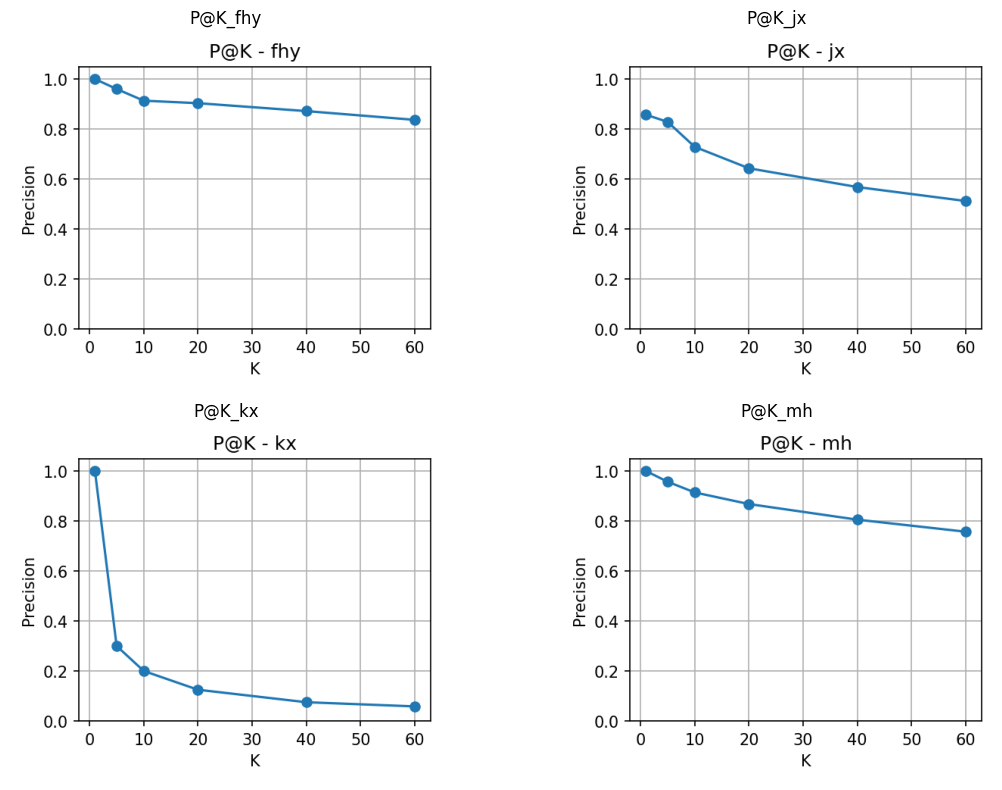

In [14]:
sample_curve_paths = sorted(pk_curve_dir.glob("P@K_*.png"))[:4]

plt.figure(figsize=(12, 8))

for i, p in enumerate(sample_curve_paths, 1):
    img = Image.open(p)
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.stem)

plt.tight_layout()
plt.show()

In [15]:
import easyocr

reader = easyocr.Reader(["ch_sim", "en"], gpu=torch.cuda.is_available())

print("EasyOCR loaded.")

EasyOCR loaded.


In [16]:
def draw_easyocr_detect_only(img_path, save_path):
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    horizontal_list, free_list = reader.detect(img_np)

    draw = ImageDraw.Draw(img)
    count = 0

    # horizontal_list: [ [x_min, x_max, y_min, y_max], ... ]
    if horizontal_list and horizontal_list[0]:
        for box in horizontal_list[0]:
            x_min, x_max, y_min, y_max = map(int, box)
            draw.rectangle([x_min, y_min, x_max, y_max], width=4)
            count += 1

    # free_list: 四点框
    if free_list and free_list[0]:
        for box in free_list[0]:
            pts = [(int(x), int(y)) for x, y in box]
            draw.line(pts + [pts[0]], width=4)
            count += 1

    img.save(save_path)
    return count

In [17]:
candidate_dir = output_root / "text_detection_detectonly_preview"
candidate_dir.mkdir(parents=True, exist_ok=True)

good_candidates = []

for lm in LANDMARKS:
    imgs = [p for p in det_img_paths if get_label(p) == lm]
    print("\n类别:", lm, "图片数:", len(imgs))

    count_good = 0

    for img_path in imgs[:80]:
        save_path = candidate_dir / f"{lm}_{img_path.stem}_detectonly.jpg"
        box_count = draw_easyocr_detect_only(img_path, save_path)

        if box_count > 0:
            print("  有检测:", img_path.name, "框数:", box_count)
            good_candidates.append(img_path)
            count_good += 1

        if count_good >= 5:
            break

print("\n候选图数量:", len(good_candidates))


类别: fhy 图片数: 249
  有检测: fhy-0120240508151840.jpg 框数: 3
  有检测: fhy-04qgjnsjosp902psvnz.png 框数: 2
  有检测: fhy-0589095011.png 框数: 2
  有检测: fhy-09djfb.png 框数: 5
  有检测: fhy-1746580766808.jpg 框数: 2

类别: jx 图片数: 18
  有检测: jx-12bn3jol13.jpg 框数: 5
  有检测: jx-1nl3llnk.jpg 框数: 3
  有检测: jx-788bdc05cbd02a07b9ffd3018211af82.jpg 框数: 1
  有检测: jx-c415cdae3732c6339cbf8a0a01ffd084.jpg 框数: 1
  有检测: jx-dbd05bf5-cec6-4c8a-858b-49feabafe2fe.png 框数: 4

类别: kx 图片数: 47
  有检测: kx-1ac1815f-6535-4968-93f7-45ba326e7a56.png 框数: 1
  有检测: kx-1vgyuhy.jpg 框数: 1
  有检测: kx-20260511140016_128_105(1).jpg 框数: 1
  有检测: kx-20260511140021_133_105(1).jpg 框数: 4
  有检测: kx-34133413e1c563fe28c70f812d5d6408.jpg 框数: 3

类别: mh 图片数: 245
  有检测: mh-00iii0wer.jpg 框数: 2
  有检测: mh-0513a4fad192097469b24a235baf8312.jpg 框数: 3
  有检测: mh-091fbnqpasdm.jpeg 框数: 3
  有检测: mh-092r0924r2owof.jpg 框数: 2
  有检测: mh-0b18e68c28c84bb1c8d2c75e43081deb.jpg 框数: 2

类别: nm 图片数: 143
  有检测: nm-103br8f0peh9g.jpeg 框数: 2
  有检测: nm-10m260jh860.jpg 框数: 3
  有检测: nm-1437wdx

In [18]:
selected = []

for lm in LANDMARKS:
    lm_good = [p for p in good_candidates if get_label(p) == lm]
    chosen = lm_good[:2]
    selected.extend(chosen)
    print(lm, "最终选择:", [p.name for p in chosen])

print("总计:", len(selected))
summary = []

for img_path in selected:
    lm = get_label(img_path)
    save_path = text_det_dir / f"{lm}_{img_path.stem}_detectonly.jpg"

    box_count = draw_easyocr_detect_only(img_path, save_path)

    summary.append({
        "landmark": lm,
        "image": img_path.name,
        "box_count": box_count,
        "output": str(save_path),
        "manual_eval": "待人工核验"
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(text_det_dir / "text_detection_summary.csv", index=False, encoding="utf-8-sig")

print("文字检测结果已保存到:", text_det_dir.resolve())
print("共生成:", len(summary_df), "张")
summary_df

fhy 最终选择: ['fhy-0120240508151840.jpg', 'fhy-04qgjnsjosp902psvnz.png']
jx 最终选择: ['jx-12bn3jol13.jpg', 'jx-1nl3llnk.jpg']
kx 最终选择: ['kx-1ac1815f-6535-4968-93f7-45ba326e7a56.png', 'kx-1vgyuhy.jpg']
mh 最终选择: ['mh-00iii0wer.jpg', 'mh-0513a4fad192097469b24a235baf8312.jpg']
nm 最终选择: ['nm-103br8f0peh9g.jpeg', 'nm-10m260jh860.jpg']
sjz 最终选择: ['sjz-10448bd820d0602c50b232c97b6f5a43.jpg', 'sjz-16165huihuh.jpg']
sy 最终选择: ['sy-015kcv.png', 'sy-09f9f9f9f.jpg']
tsg 最终选择: ['tsg-01.png', 'tsg-04.jpg']
ty 最终选择: ['ty-02djdb.png', 'ty-1455ihdd781.jpg']
yf 最终选择: ['yf-cxvbhjvsbfdiw.jpg', 'yf-dnsjfgki43534.jpg']
yk 最终选择: ['yk-1bvjiji.jpg', 'yk-20260511181541_151_105.jpg']
zx 最终选择: ['zx-0924r9420fwf.jpg', 'zx-09ucbc.png']
总计: 24
文字检测结果已保存到: C:\Users\施琳\outputs\text_detection_detectonly_final
共生成: 24 张


,landmark,image,box_count,output,manual_eval
0,fhy,fhy-0120240508151840.jpg,3,outputs\text_detection_detectonly_final\fhy_fh...,待人工核验
1,fhy,fhy-04qgjnsjosp902psvnz.png,2,outputs\text_detection_detectonly_final\fhy_fh...,待人工核验
2,jx,jx-12bn3jol13.jpg,5,outputs\text_detection_detectonly_final\jx_jx-...,待人工核验
3,jx,jx-1nl3llnk.jpg,3,outputs\text_detection_detectonly_final\jx_jx-...,待人工核验
4,kx,kx-1ac1815f-6535-4968-93f7-45ba326e7a56.png,1,outputs\text_detection_detectonly_final\kx_kx-...,待人工核验
5,kx,kx-1vgyuhy.jpg,1,outputs\text_detection_detectonly_final\kx_kx-...,待人工核验
6,mh,mh-00iii0wer.jpg,2,outputs\text_detection_detectonly_final\mh_mh-...,待人工核验
7,mh,mh-0513a4fad192097469b24a235baf8312.jpg,3,outputs\text_detection_detectonly_final\mh_mh-...,待人工核验
8,nm,nm-103br8f0peh9g.jpeg,2,outputs\text_detection_detectonly_final\nm_nm-...,待人工核验
9,nm,nm-10m260jh860.jpg,3,outputs\text_detection_detectonly_final\nm_nm-...,待人工核验


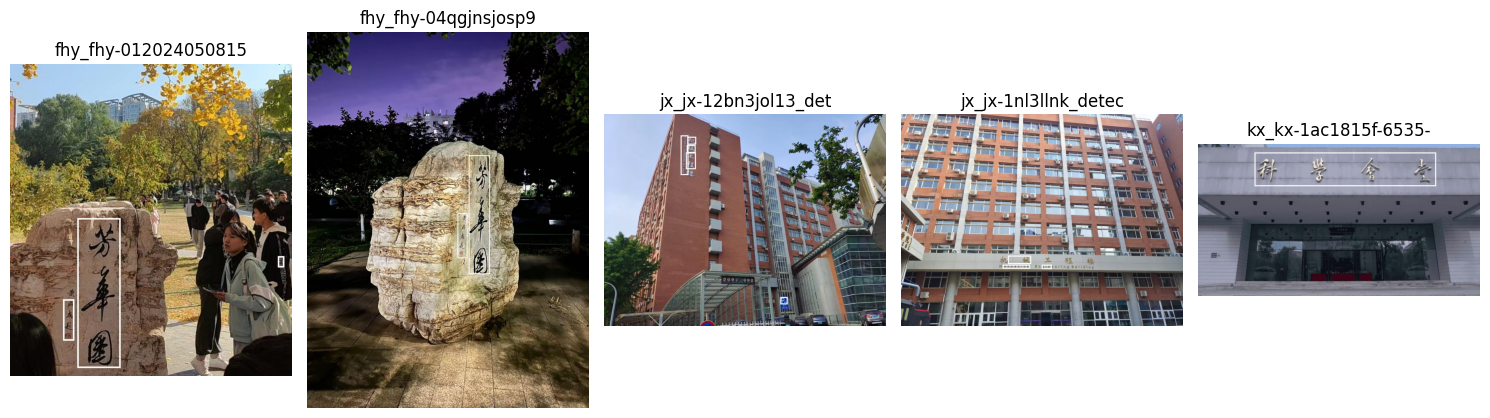

In [19]:
sample_det_paths = sorted(text_det_dir.glob("*.jpg"))[:5]

plt.figure(figsize=(15, 10))

for i, p in enumerate(sample_det_paths, 1):
    img = Image.open(p)
    plt.subplot(1, len(sample_det_paths), i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name[:20])

plt.tight_layout()
plt.show()

In [20]:
print("=== 输出文件检查 ===")
print("P@K 曲线数量:", len(list(pk_curve_dir.glob("P@K_*.png"))))
print("文字检测可视化数量:", len(list(text_det_dir.glob("*.jpg"))))
print("P@K 结果表:", (pk_curve_dir / "retrieval_pk_results.csv").exists())
print("文字检测 summary:", (text_det_dir / "text_detection_summary.csv").exists())

print("\n项目输出目录:", output_root.resolve())

=== 输出文件检查 ===
P@K 曲线数量: 12
文字检测可视化数量: 24
P@K 结果表: True
文字检测 summary: True

项目输出目录: C:\Users\施琳\outputs
